# Milestone 1: Exploratory Data Analysis
Heart Disease Risk Prediction (BRFSS 2022)

Covers the September milestone:
- feature typing / encoding decisions
- missing data audit
- correlation matrix + target relationships
- distributions, bivariate analysis, summary stats
- fixed-seed, stratified train/validation/test split


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

RANDOM_SEED = 42  # fixed seed used everywhere below for reproducibility

In [2]:
DATA_PATH = "../Data/heart_2022_with_nans.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(445132, 40)


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,Never smoked,Not at all (right now),No,"White only, Non-Hispanic",Age 80 or older,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 80 or older,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 55 to 59,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,No,No,Yes,No,No,No,No,Yes,No,No,No,No,No,No,No,Current smoker - now smokes some days,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",NaN,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 40 to 44,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


## 2. Feature typing
Document each column's storage dtype and its semantic type (numerical continuous,
numerical discrete, binary categorical, multi-class categorical, free text).
This will help determine how to encode it later.

In [3]:
dtype_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'sample_values': [df[c].dropna().unique()[:5] for c in df.columns]
})
dtype_summary

,dtype,n_unique,sample_values
State,str,54,"[Alabama, Alaska, Arizona, Arkansas, California]"
Sex,str,2,"[Female, Male]"
GeneralHealth,str,5,"[Very good, Excellent, Fair, Poor, Good]"
PhysicalHealthDays,float64,31,"[0.0, 2.0, 1.0, 8.0, 5.0]"
MentalHealthDays,float64,31,"[0.0, 3.0, 9.0, 5.0, 15.0]"
LastCheckupTime,str,4,[Within past year (anytime less than 12 months...
PhysicalActivities,str,2,"[No, Yes]"
SleepHours,float64,24,"[8.0, 6.0, 5.0, 7.0, 9.0]"
RemovedTeeth,str,4,"[None of them, 1 to 5, 6 or more, but not all,..."
HadHeartAttack,str,2,"[No, Yes]"


| Column | Data Type |
|---|---|
| State | Categorical (String) |
| Sex | Categorical (Binary) |
| GeneralHealth | Categorical (Ordinal) |
| PhysicalHealthDays | Numerical (Float) |
| MentalHealthDays | Numerical (Float) |
| LastCheckupTime | Categorical (Ordinal) |
| PhysicalActivities | Categorical (Binary) |
| SleepHours | Numerical (Float) |
| RemovedTeeth | Categorical (Ordinal) |
| HadHeartAttack | Categorical (Binary) |
| HadAngina | Categorical (Binary) |
| HadStroke | Categorical (Binary) |
| HadAsthma | Categorical (Binary) |
| HadSkinCancer | Categorical (Binary) |
| HadCOPD | Categorical (Binary) |
| HadDepressiveDisorder | Categorical (Binary) |
| HadKidneyDisease | Categorical (Binary) |
| HadArthritis | Categorical (Binary) |
| HadDiabetes | Categorical (Nominal) |
| DeafOrHardOfHearing | Categorical (Binary) |
| BlindOrVisionDifficulty | Categorical (Binary) |
| DifficultyConcentrating | Categorical (Binary) |
| DifficultyWalking | Categorical (Binary) |
| DifficultyDressingBathing | Categorical (Binary) |
| DifficultyErrands | Categorical (Binary) |
| SmokerStatus | Categorical (Nominal) |
| ECigaretteUsage | Categorical (Nominal) |
| ChestScan | Categorical (Binary) |
| RaceEthnicityCategory | Categorical (Nominal) |
| AgeCategory | Categorical (Ordinal) |
| HeightInMeters | Numerical (Float) |
| WeightInKilograms | Numerical (Float) |
| BMI | Numerical (Float) |
| AlcoholDrinkers | Categorical (Binary) |
| HIVTesting | Categorical (Binary) |
| FluVaxLast12 | Categorical (Binary) |
| PneumoVaxEver | Categorical (Binary) |
| TetanusLast10Tdap | Categorical (Nominal) |
| HighRiskLastYear | Categorical (Binary) |
| CovidPos | Categorical (Nominal) |

## 3. Missing data audit
For each column: how many values are missing, and what's a defensible handling strategy
(drop rows, impute mean/median/mode, impute with a model, or add a "missing" indicator
category)?

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing_summary = pd.DataFrame({'n_missing': missing})
missing_summary[missing_summary['n_missing'] > 0]

,n_missing
TetanusLast10Tdap,82516
PneumoVaxEver,77040
HIVTesting,66127
ChestScan,56046
CovidPos,50764
HighRiskLastYear,50623
BMI,48806
FluVaxLast12,47121
AlcoholDrinkers,46574
WeightInKilograms,42078


In [5]:
missing_summary[missing_summary['n_missing'] == 0]

,n_missing
Sex,0
State,0


In [6]:
# TODO: document your per-column decision

# Sex and state do not have missing values.

# HadHeartAttack is our target variable and has 3065 missing values.
# These rows will be removed since they will not be helpful in our analysis.
df = df[df['HadHeartAttack'].notna()]

# Check how many more NA values drop after removing those missing rows
print(df.shape)
missing_updated = df.isna().sum().sort_values(ascending=False)
missing_summary_updated = pd.DataFrame({'n_missing': missing_updated})
missing_summary_updated[missing_summary_updated['n_missing'] >= 0]

(442067, 40)


,n_missing
TetanusLast10Tdap,81574
PneumoVaxEver,76210
HIVTesting,65310
ChestScan,55288
CovidPos,50127
HighRiskLastYear,49985
BMI,48110
FluVaxLast12,46477
AlcoholDrinkers,45937
WeightInKilograms,41466


In [7]:
# Displaying percentages of missing values
missing_counts_perc = df.isna().sum().sort_values(ascending=False)
missing_percentages = (df.isna().mean() * 100).round(2)
missing_percentages_summary = pd.DataFrame({'n_missing_%': missing_percentages})
missing_percentages[missing_percentages_summary['n_missing_%'] > 0].sort_values(ascending=False)

TetanusLast10Tdap            18.45
PneumoVaxEver                17.24
HIVTesting                   14.77
ChestScan                    12.51
CovidPos                     11.34
HighRiskLastYear             11.31
BMI                          10.88
FluVaxLast12                 10.51
AlcoholDrinkers              10.39
WeightInKilograms             9.38
ECigaretteUsage               7.95
SmokerStatus                  7.90
HeightInMeters                6.37
DifficultyErrands             5.71
DifficultyConcentrating       5.38
DifficultyWalking             5.34
DifficultyDressingBathing     5.32
BlindOrVisionDifficulty       4.79
DeafOrHardOfHearing           4.59
RaceEthnicityCategory         3.10
RemovedTeeth                  2.49
PhysicalHealthDays            2.40
AgeCategory                   1.99
MentalHealthDays              1.99
LastCheckupTime               1.82
SleepHours                    1.18
HadAngina                     0.81
HadSkinCancer                 0.63
HadDepressiveDisorde

In [8]:
# Each column's missing values take up less than 10% of its rows, majority being under 3%.
# Therefore, we do not need to drop any columns.

# Now, we can perform a stratisfied split on the dataset.
X = df.drop(columns = ['HadHeartAttack'])
y = df['HadHeartAttack']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# Check shapes after splitting
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}\n")
print(f"Target positive rate in original data: {y.value_counts(normalize=True)}\n")
print(f"Target positive rate in training set: {y_train.value_counts(normalize=True)}\n")
print(f"Target positive rate in test set: {y_test.value_counts(normalize=True)}")

X_train: (353653, 39)
y_train: (353653,)
X_test: (88414, 39)
y_test: (88414,)

Target positive rate in original data: HadHeartAttack
No     0.943203
Yes    0.056797
Name: proportion, dtype: float64

Target positive rate in training set: HadHeartAttack
No     0.943204
Yes    0.056796
Name: proportion, dtype: float64

Target positive rate in test set: HadHeartAttack
No     0.943199
Yes    0.056801
Name: proportion, dtype: float64


In [9]:
# Because we are using XGBoost, the model is able to handle NA values.
# We can explore how well utilizing this algorithm will impact our model
# and revise EDA and data cleaning steps as needed.

## 4. Correlation matrix
Numeric-only Pearson correlation first, then rank features by their correlation with the
target. For categorical predictors, a full correlation matrix isn't meaningful as-is --
consider encoding them before including them.

In [10]:
# Additional imports
from pathlib import Path
from IPython.display import display


TARGET = 'HadHeartAttack'

In [11]:
# Reuse Section 3's training rows (load from disk only if running standalone).
if 'X_train' in globals():
    train = df.loc[X_train.index].copy()
    print('Using Section 3 training rows')
else:
    from sklearn.model_selection import train_test_split
    _df = pd.read_csv(DATA_PATH, low_memory=False)
    _df = _df[_df[TARGET].notna()].copy()
    train, _ = train_test_split(_df, test_size=0.2, random_state=RANDOM_SEED,
                                stratify=_df[TARGET])
    print('Section 3 split not found; rebuilt an 80/20 split with seed 42')

train['target'] = (train[TARGET] == 'Yes').astype(int)
print(f"Training rows : {len(train):,}")
print(f"Positive rate : {train['target'].mean():.2%}")

Using Section 3 training rows
Training rows : 353,653
Positive rate : 5.68%


6 numeric columns: ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 'HeightInMeters', 'WeightInKilograms', 'BMI']


,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
PhysicalHealthDays,1.000,0.321,-0.057,-0.050,0.074,0.114
MentalHealthDays,0.321,1.000,-0.129,-0.050,0.040,0.076
SleepHours,-0.057,-0.129,1.000,-0.014,-0.053,-0.051
HeightInMeters,-0.050,-0.050,-0.014,1.000,0.467,-0.028
WeightInKilograms,0.074,0.040,-0.053,0.467,1.000,0.860
BMI,0.114,0.076,-0.051,-0.028,0.860,1.000


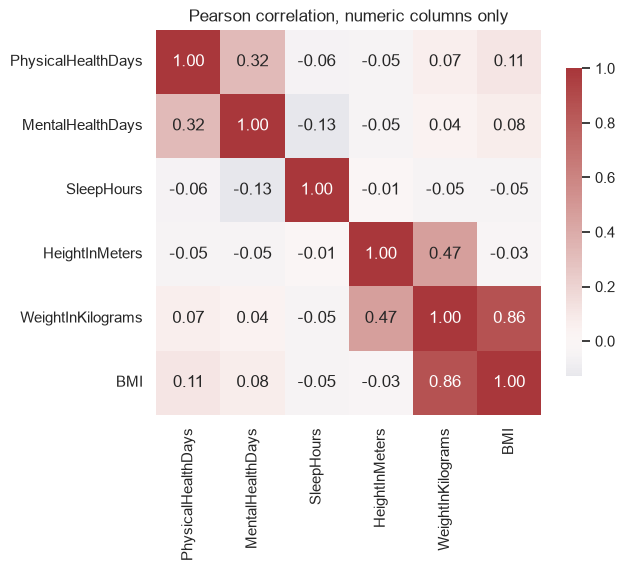

In [12]:
# Pearson corrleation, num columns only

numeric_cols = [c for c in train.select_dtypes(include='number').columns if c != 'target']
print(f"{len(numeric_cols)} numeric columns:", numeric_cols)

pearson_numeric = train[numeric_cols].corr()     # pairwise-complete by default
display(pearson_numeric.round(3))

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(pearson_numeric, annot=True, fmt='.2f', cmap='vlag', center=0,
            square=True, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Pearson correlation, numeric columns only')
plt.show()

In [13]:
# Num features ranked by correlation with Target

numeric_vs_target = (train[numeric_cols].corrwith(train['target'])
                     .sort_values(key=abs, ascending=False)
                     .rename('pearson_r').to_frame())
display(numeric_vs_target.round(4))

,pearson_r
PhysicalHealthDays,0.1449
WeightInKilograms,0.0376
BMI,0.0305
MentalHealthDays,0.0303
HeightInMeters,0.0207
SleepHours,0.0031


In [14]:
# Encode categorical predictors

ORDINAL_MAPS = {
    'GeneralHealth': {'Poor': 0, 'Fair': 1, 'Good': 2, 'Very good': 3, 'Excellent': 4},
    'RemovedTeeth': {'None of them': 0, '1 to 5': 1, '6 or more, but not all': 2, 'All': 3},
    'LastCheckupTime': {
        'Within past year (anytime less than 12 months ago)': 0,
        'Within past 2 years (1 year but less than 2 years ago)': 1,
        'Within past 5 years (2 years but less than 5 years ago)': 2,
        '5 or more years ago': 3},
    'SmokerStatus': {
        'Never smoked': 0, 'Former smoker': 1,
        'Current smoker - now smokes some days': 2,
        'Current smoker - now smokes every day': 3},
    'ECigaretteUsage': {
        'Never used e-cigarettes in my entire life': 0, 'Not at all (right now)': 1,
        'Use them some days': 2, 'Use them every day': 3},
}
AGE_COL = 'AgeCategory'          # ranked by its first number: 'Age 18 to 24' -> 18

cat_cols = [c for c in train.columns if c not in numeric_cols + [TARGET, 'target']]
ordinal_cols = [c for c in cat_cols if c in ORDINAL_MAPS or c == AGE_COL]
binary_cols = [c for c in cat_cols
               if c not in ordinal_cols and train[c].nunique(dropna=True) == 2]
nominal_cols = [c for c in cat_cols if c not in ordinal_cols + binary_cols]

encoded = train[numeric_cols].copy()

for col in binary_cols:                       # 0 / 1
    levels = sorted(train[col].dropna().unique())
    positive = 'Yes' if 'Yes' in levels else levels[-1]
    encoded[col] = train[col].eq(positive).astype(float).where(train[col].notna())
    print(f"binary   {col:<28} {positive} = 1")

for col in ordinal_cols:                      # integer ranks
    if col == AGE_COL:
        first_number = train[col].astype('string').str.extract(r'(\d+)', expand=False)
        encoded[col] = pd.to_numeric(first_number, errors='coerce')
    else:
        encoded[col] = train[col].map(ORDINAL_MAPS[col])
    unmapped = train.loc[encoded[col].isna() & train[col].notna(), col].unique()
    note = f"  !! unmapped: {list(unmapped)}" if len(unmapped) else ''
    print(f"ordinal  {col:<28} {int(encoded[col].min())} to {int(encoded[col].max())}{note}")

dummies = pd.get_dummies(train[nominal_cols], dummy_na=True, dtype=float)
encoded = pd.concat([encoded, dummies], axis=1).astype('float32')
for col in nominal_cols:
    print(f"one-hot  {col:<28} {train[col].nunique(dropna=True)} levels")

print()
print(f"{len(numeric_cols)} numeric + {len(binary_cols)} binary + {len(ordinal_cols)} ordinal "
      f"+ {len(nominal_cols)} one-hot ({dummies.shape[1]} columns) = {encoded.shape[1]} features")

binary   Sex                          Male = 1
binary   PhysicalActivities           Yes = 1
binary   HadAngina                    Yes = 1
binary   HadStroke                    Yes = 1
binary   HadAsthma                    Yes = 1
binary   HadSkinCancer                Yes = 1
binary   HadCOPD                      Yes = 1
binary   HadDepressiveDisorder        Yes = 1
binary   HadKidneyDisease             Yes = 1
binary   HadArthritis                 Yes = 1
binary   DeafOrHardOfHearing          Yes = 1
binary   BlindOrVisionDifficulty      Yes = 1
binary   DifficultyConcentrating      Yes = 1
binary   DifficultyWalking            Yes = 1
binary   DifficultyDressingBathing    Yes = 1
binary   DifficultyErrands            Yes = 1
binary   ChestScan                    Yes = 1
binary   AlcoholDrinkers              Yes = 1
binary   HIVTesting                   Yes = 1
binary   FluVaxLast12                 Yes = 1
binary   PneumoVaxEver                Yes = 1
binary   HighRiskLastYear        

/Users/eunjaelee/Desktop/Accenture_Healthcare_2A/Healthcare-2A-predicting-heart-disease-risk-from-health-survey-indicators/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/eunjaelee/Desktop/Accenture_Healthcare_2A/Healthcare-2A-predicting-heart-disease-risk-from-health-survey-indicators/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,pearson_r
HadAngina,0.4438
HadStroke,0.1893
GeneralHealth,-0.1892
AgeCategory,0.1783
RemovedTeeth,0.1754
ChestScan,0.1740
DifficultyWalking,0.1681
HadDiabetes_Yes,0.1497
HadCOPD,0.1452
PhysicalHealthDays,0.1449


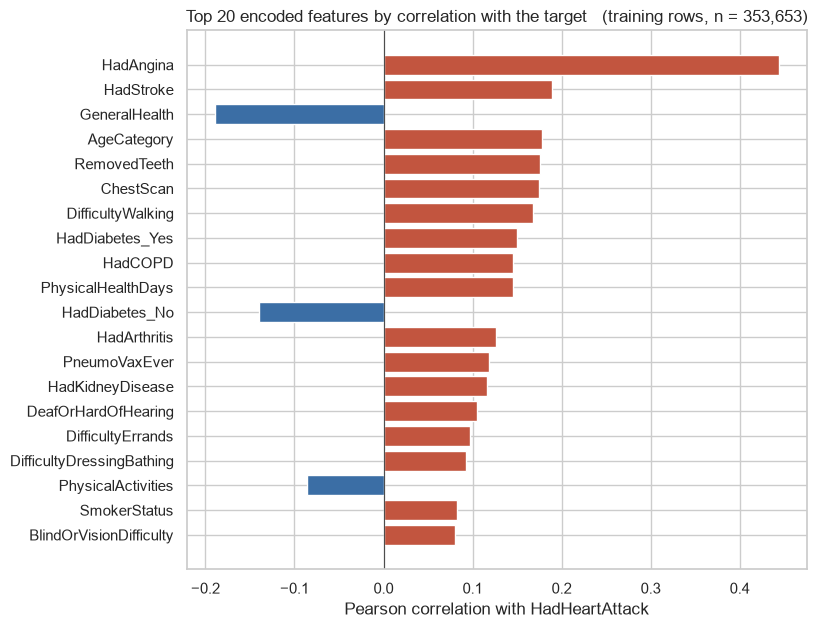

In [15]:
# All encoded features ranked by correlation with Target

all_vs_target = (encoded.corrwith(train['target'])
                 .sort_values(key=abs, ascending=False)
                 .rename('pearson_r').to_frame())
display(all_vs_target.head(25).round(4))

top20 = all_vs_target.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20.index, top20['pearson_r'],
        color=np.where(top20['pearson_r'] > 0, '#c2553f', '#3b6ea5'))
ax.axvline(0, color='0.3', linewidth=0.8)
ax.set_xlabel(f'Pearson correlation with {TARGET}')
ax.set_title(f'Top 20 encoded features by correlation with the target'
             f'   (training rows, n = {len(train):,})')
plt.show()

Full correlation matrix: (109, 109)


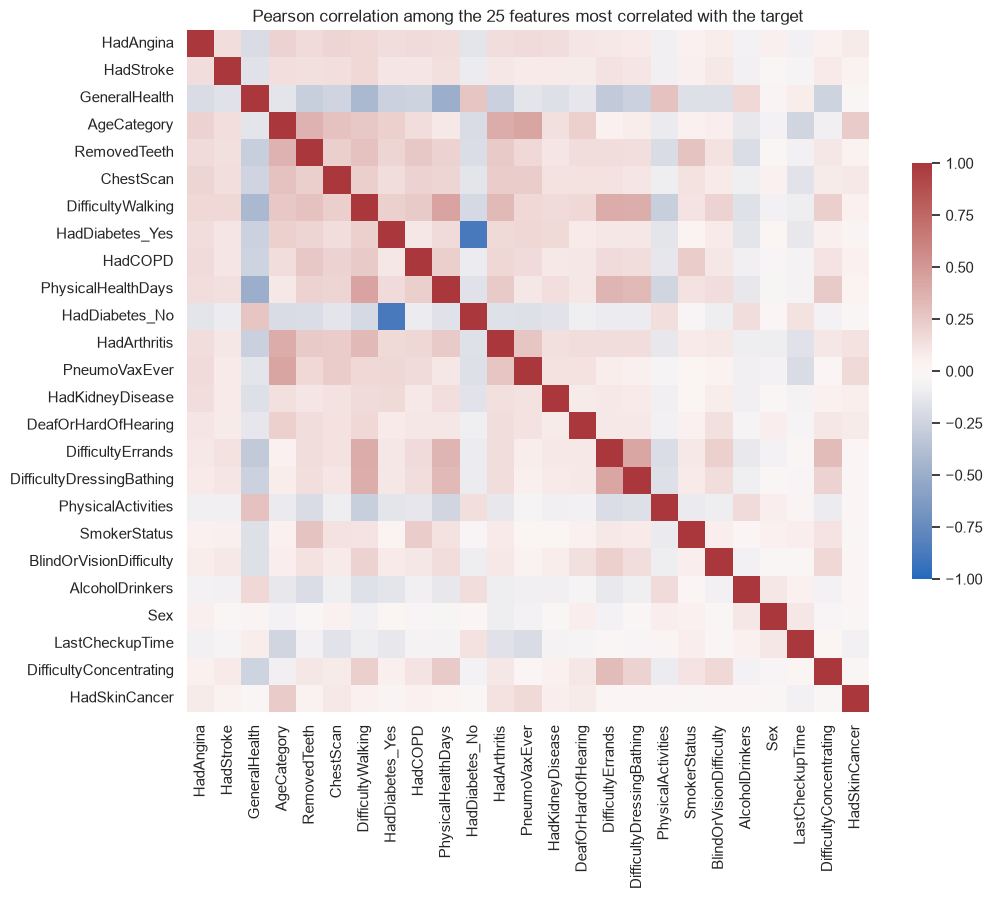

In [16]:
# Correlation matrix including encoded predictors

full_corr = encoded.corr()
print('Full correlation matrix:', full_corr.shape)

top25 = all_vs_target.head(25).index.tolist()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(full_corr.loc[top25, top25], cmap='vlag', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': .6}, ax=ax)
ax.set_title('Pearson correlation among the 25 features most correlated with the target')
plt.show()

## 5. Distributions, bivariate analysis, and summary statistics

In [17]:
df[numeric_cols].describe().T  # mean, std, min, max, quartiles for every numeric column

,count,mean,std,min,25%,50%,75%,max
PhysicalHealthDays,431470.0,4.322639,8.662400,0.00,0.00,0.00,3.00,30.00
MentalHealthDays,433275.0,4.371406,8.372727,0.00,0.00,0.00,5.00,30.00
SleepHours,436871.0,7.023268,1.496407,1.00,6.00,7.00,8.00,24.00
HeightInMeters,413926.0,1.702758,0.107142,0.91,1.63,1.70,1.78,2.41
WeightInKilograms,400601.0,83.077346,21.439283,22.68,68.04,80.74,95.25,292.57
BMI,393957.0,28.527818,6.550960,12.02,24.13,27.44,31.74,99.64


In [18]:
# Univariate: distribution of each numeric feature

In [19]:
# Bivariate: each numeric feature vs. target

In [20]:
# Bivariate for categorical features

## 6. Train / validation / test split

In [21]:
# First split off the test set, then split train/val from what remains